In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
!pwd

/home/leostre/Рабочий стол/py-boost/experiments


In [7]:
import os 
for file in os.listdir('data'):
    try:
        np.load('data/'+file)
        print(f'{file} success')
    except:
        print(f'{file} is missing')

grad_history_spambase_94.npy success
hess_history_default_credit_card_350.npy success
grad_hess_histories.zip success
hess_history_yeast_110.npy success
grad_history_default_credit_card_350.npy success
grad_history_yeast_110.npy is missing
hess_history_wine_quality_186.npy success
grad_history_wine_quality_186.npy success
hess_history_spambase_94.npy success


In [35]:
datasets = [
    'yeast',
    'spambase_94',
    'default_credit_card_350',
    'wine_quality_186'
]

In [36]:
def download_data(dataset_name):
    grad = np.load(f'data/grad_history_{dataset_name}.npy')
    hess =  np.load(f'data/hess_history_{dataset_name}.npy')

    grad = grad.reshape(-1, grad.shape[-2], grad.shape[-1])
    hess = hess.reshape(-1, hess.shape[-2], hess.shape[-1])
    return grad, hess

In [119]:
grad, hess = download_data('yeast')

In [ ]:
grad, hess = download_data('spambase_94')

In [92]:
np.std(grad, axis=1).shape

(1800, 2)

In [93]:
windows = np.lib.stride_tricks.sliding_window_view(grad, 7, axis=1)

In [95]:
windows.shape, grad.shape

((1800, 3674, 2, 7), (1800, 3680, 2))

In [88]:
from itertools import product
from scipy.ndimage import gaussian_filter1d

def viz_norm(dataset_name):
    fig, axes = plt.subplots(2, 1, sharex=True)
    fig.set_figwidth(10)
    data = dict(zip(['grad', 'hess'], download_data(dataset_name)))
    ords = ['fro', 'nuc']
    for ord, (tp, mtrs) in product(ords, data.items()):
        norms = np.linalg.norm(mtrs, axis=(1, 2), ord=ord, )
        axes[0].plot(
            norms, label=tp + '_' + ord,  
        )
        mtrs = gaussian_filter1d(mtrs, 2, axis=0)
        first_der = np.diff(norms, 1, 0)
        axes[1].plot(
            first_der, label=tp + '_' + ord,  
        )
    axes[0].grid()
    axes[1].grid()
    axes[0].set_xlabel('Epochs')
    axes[1].set_xlabel('Epochs')
    axes[0].set_ylabel('Norm')
    fig.suptitle(dataset_name)
    axes[0].set_title('0-der')
    axes[1].set_title('1-der')
    plt.legend()
    plt.show()

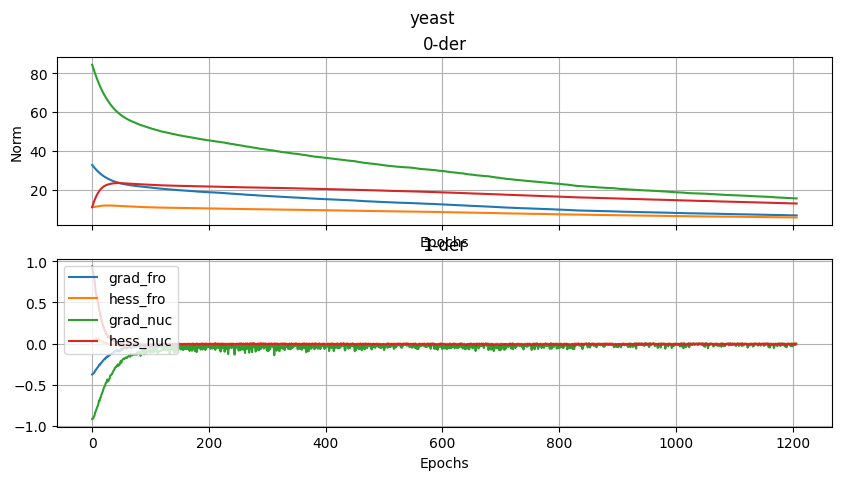

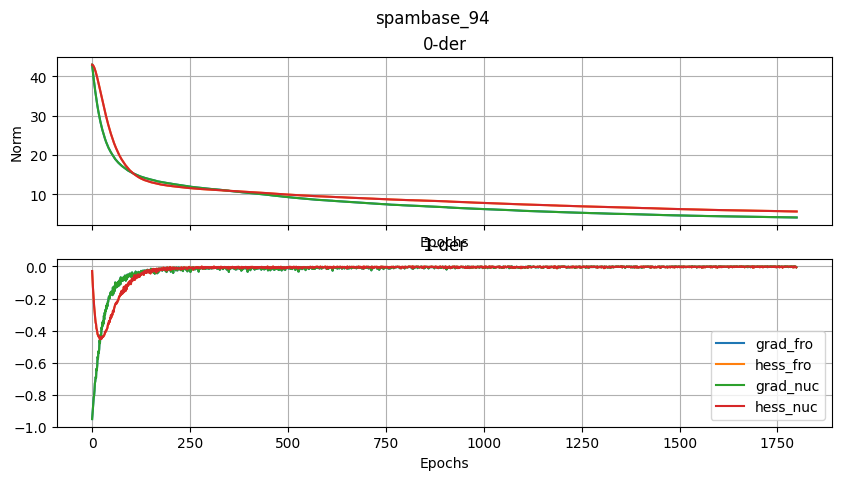

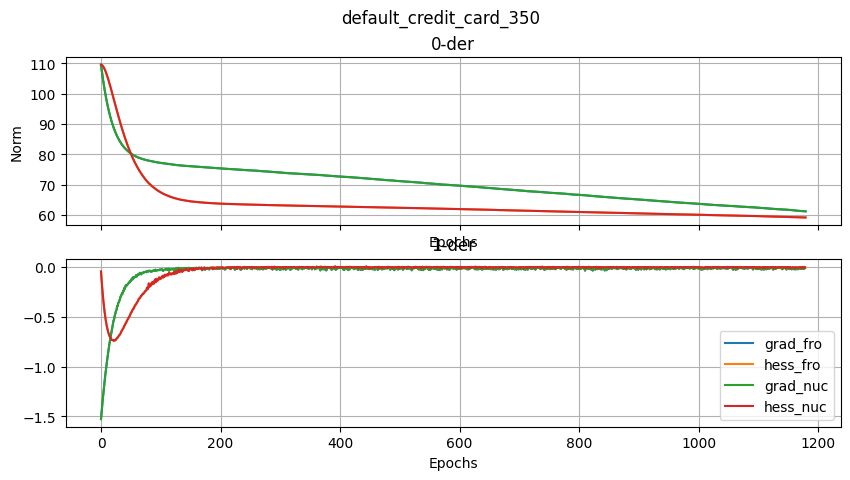

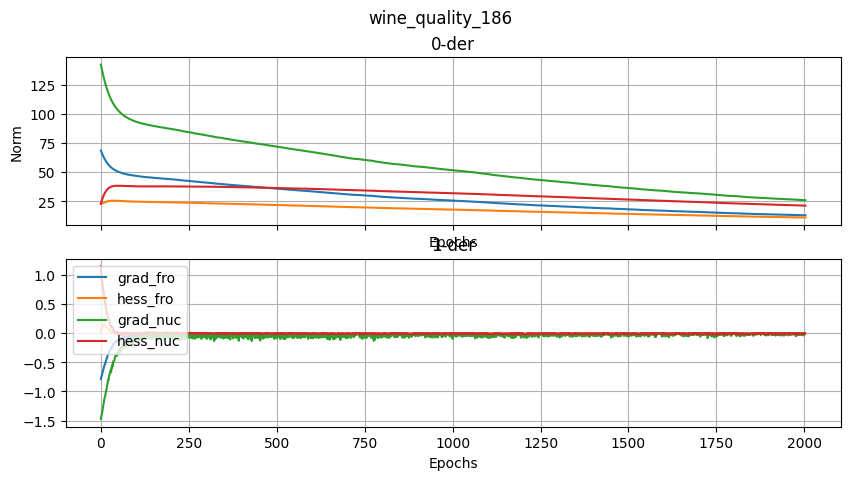

In [89]:
for dataset in datasets:
    viz_norm(dataset)

## STD for datasets in time by class

In [144]:
from functools import partial

def sliding_statistic(
    grad, hess, window_size, axis=0, func=partial(np.std, axis=-1), log=True, squash=True
    ):
    if not squash:
        for i in range(grad.shape[-1]):
            fig, axes = plt.subplots(1, 2)
            fig.set_figwidth(10)
            for ax, data in zip(axes, (grad[..., i], hess[..., i])):
                windows = np.lib.stride_tricks.sliding_window_view(data, window_size, axis=axis)
                statistic = func(windows)
                if log:
                    statistic = np.log(statistic)

                    ax.imshow(
                            statistic
                    )

                ax.set_title(f'Label: {i}')
            plt.show()
    else:
        fig, axes = plt.subplots(1, 2)
        fig.set_figwidth(10)
        for ax, data, title in zip(axes, (grad, hess), ('grad', 'hess')):
            windows = np.lib.stride_tricks.sliding_window_view(data, window_size, axis=axis)
            statistic = func(windows)
            if log:
                statistic = np.log(statistic)
            for i in range(statistic.shape[-1]):
                ax.plot(
                    np.mean(statistic[..., i], -1), label=i
                )
            ax.legend()
            ax.set_title(title)
            ax.grid()
        plt.show()

===============================================YEAST================================================


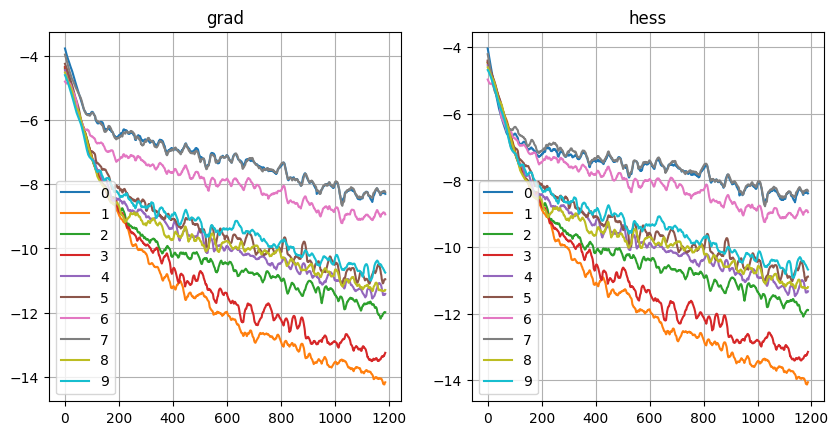

============================================SPAMBASE_94=============================================


/tmp/ipykernel_12820/1218465466.py:29: RuntimeWarning: divide by zero encountered in log
  statistic = np.log(statistic)


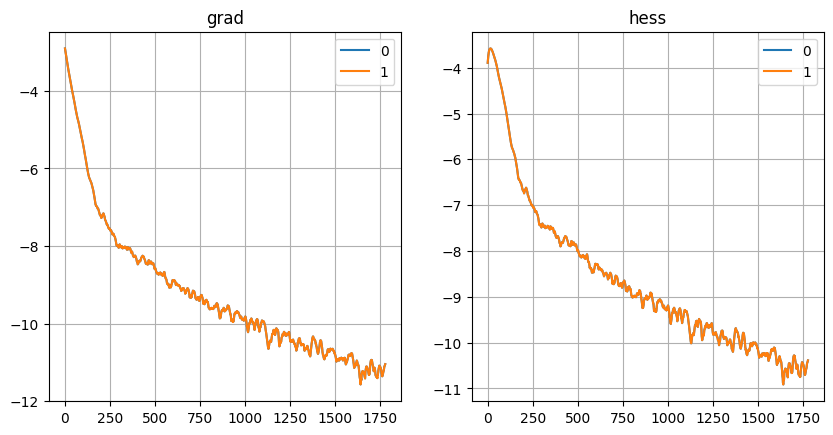

======================================DEFAULT_CREDIT_CARD_350=======================================


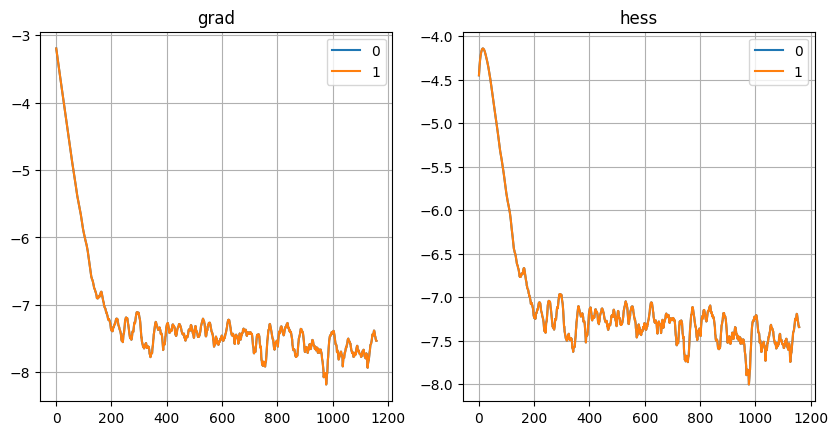

==========================================WINE_QUALITY_186==========================================


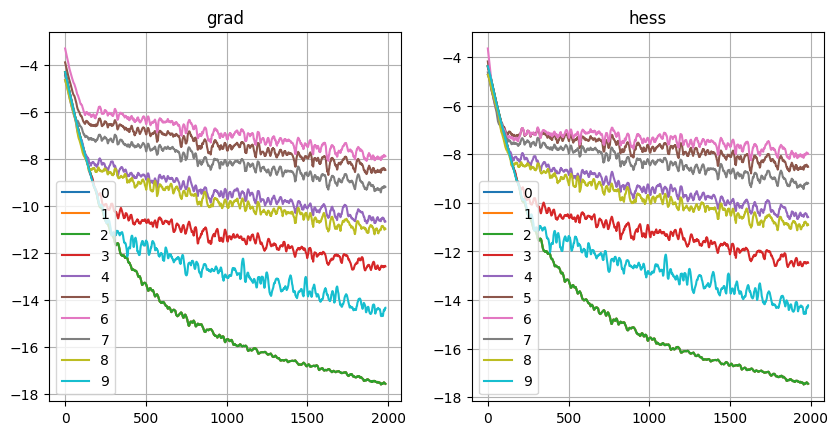

In [148]:
for dataset in datasets:
    print(dataset.upper().center(100, '='))
    sliding_statistic(*download_data(dataset), 21, func=partial(np.std, axis=-1), squash=True, log=True)

## MEANS 

===============================================YEAST================================================


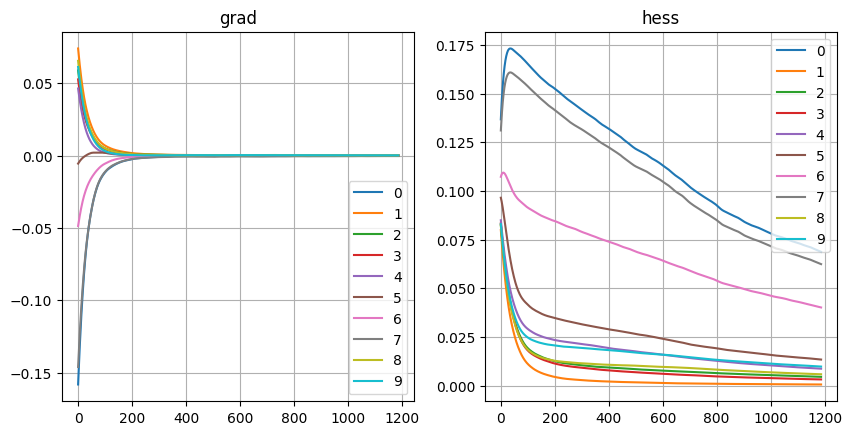

============================================SPAMBASE_94=============================================


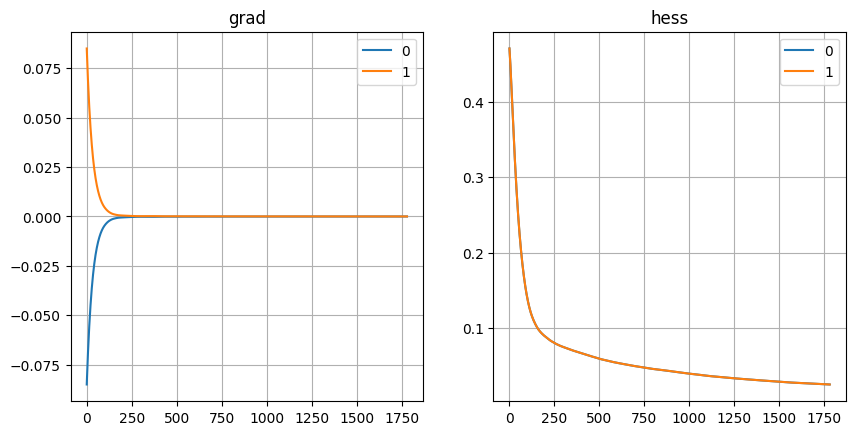

======================================DEFAULT_CREDIT_CARD_350=======================================


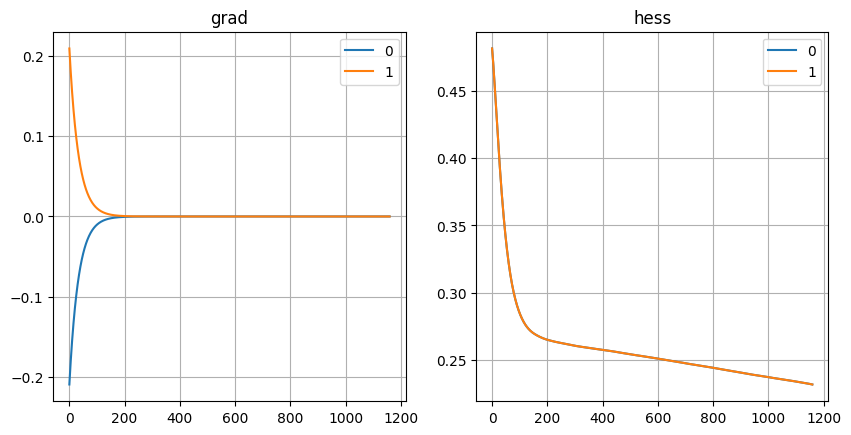

==========================================WINE_QUALITY_186==========================================


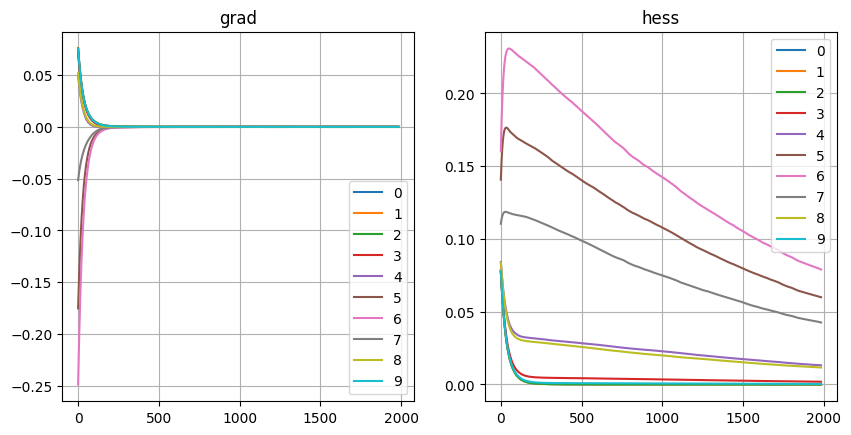

In [ ]:
for dataset in datasets:
    print(dataset.upper().center(100, '='))
    sliding_statistic(*download_data(dataset), 21, func=partial(np.s, axis=-1), squash=True, log=False)

In [155]:
np.linalg.svdvals(grad).T.shape

(10, 1208)

### SVDVals Dynamics

In [170]:
def svdvals_dynamics(grad, hess):
    fig, axes = plt.subplots(1, 2)
    fig.set_figwidth(10)
    for data, ax, label in zip(
        (grad, hess), axes, ('grad', 'hess')
    ):  
        data = np.linalg.svdvals(data)
        for i in range(data.shape[-1]):
            ax.plot(data[..., i], label='Sing.val.:' + str(i))
        ax.legend()
        ax.grid()
        ax.set_title(label)
    plt.show()

===============================================YEAST================================================


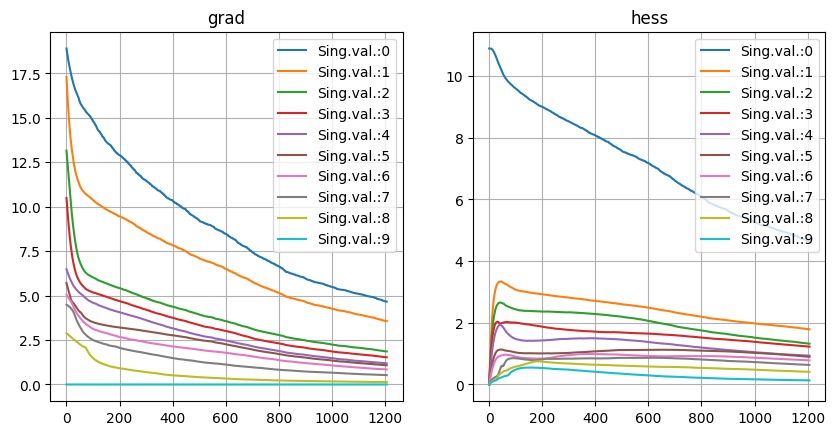

============================================SPAMBASE_94=============================================


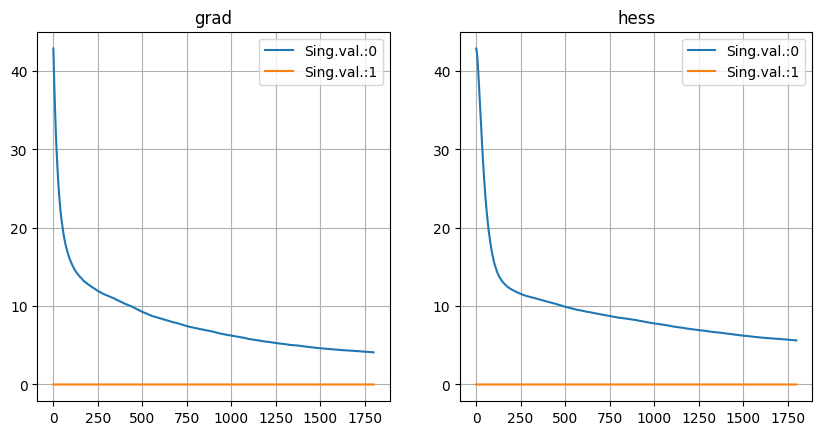

======================================DEFAULT_CREDIT_CARD_350=======================================


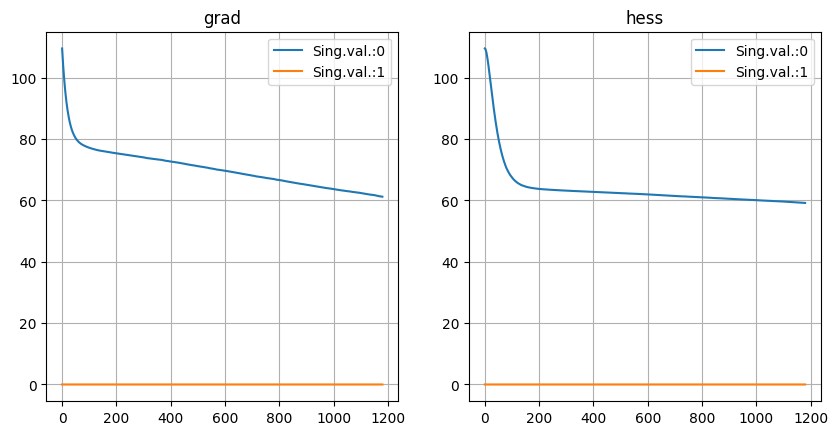

==========================================WINE_QUALITY_186==========================================


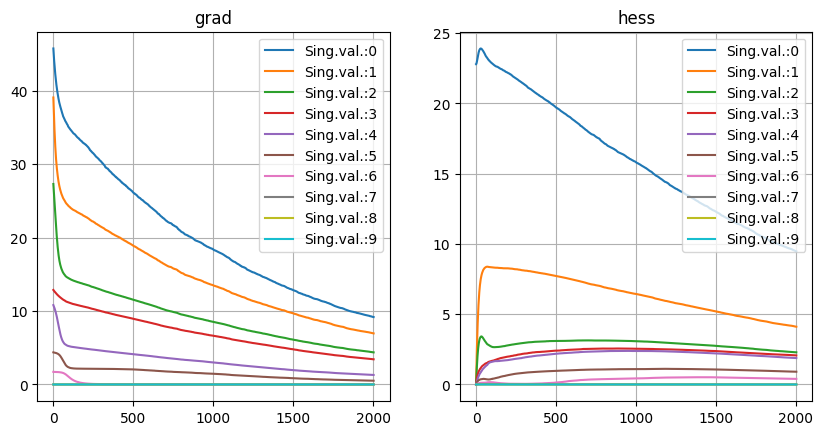

In [171]:
for dataset in datasets:
    print(dataset.upper().center(100, '='))
    svdvals_dynamics(*download_data(dataset))

In [172]:
from numpy.fft import fft, ifft



In [176]:
np.transpose(grad, (2, 0, 1))

array([[[-8.99999976e-01, -8.99999976e-01, -8.99999976e-01, ...,
          1.00000001e-01, -8.99999976e-01,  1.00000001e-01],
        [-8.86852384e-01, -8.87035966e-01, -8.92349005e-01, ...,
          9.77277681e-02, -8.98830652e-01,  9.81418490e-02],
        [-8.76864851e-01, -8.75595987e-01, -8.83836508e-01, ...,
          9.57626775e-02, -8.96492541e-01,  1.04105175e-01],
        ...,
        [-1.76511765e-01, -1.39273405e-01, -1.10449433e-01, ...,
          2.96342354e-02, -8.80600810e-02,  7.56199062e-02],
        [-1.76396728e-01, -1.39186800e-01, -1.09485269e-01, ...,
          2.96421126e-02, -8.77835751e-02,  7.56808668e-02],
        [-1.76768959e-01, -1.39190733e-01, -1.09494030e-01, ...,
          2.95710210e-02, -8.67730379e-02,  7.56207630e-02]],

       [[ 1.00000001e-01,  1.00000001e-01,  1.00000001e-01, ...,
          1.00000001e-01,  1.00000001e-01,  1.00000001e-01],
        [ 9.70248058e-02,  9.72290188e-02,  9.76416692e-02, ...,
          9.72560346e-02,  9.73279402e